# 07 Topic Modeling
Discover latent topics in customer reviews using LDA.

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load cleaned reviews
df = pd.read_csv('../data/cleaned_reviews.csv')
texts = df['reviewText_clean']

print(f'Loaded {len(texts)} reviews for topic modeling')

Loaded 20370 reviews for topic modeling


In [2]:
# Create document-term matrix
print('Creating document-term matrix...')
vectorizer = CountVectorizer(
    max_features=2000,
    min_df=5,
    max_df=0.8,
    stop_words='english'
)

doc_term_matrix = vectorizer.fit_transform(texts)
feature_names = vectorizer.get_feature_names_out()

print(f'Document-term matrix shape: {doc_term_matrix.shape}')
print(f'Vocabulary size: {len(feature_names)}')

# Save vectorizer
joblib.dump(vectorizer, '../models/lda_vectorizer.joblib')
print('LDA vectorizer saved')

Creating document-term matrix...
Document-term matrix shape: (20370, 2000)
Vocabulary size: 2000
LDA vectorizer saved


In [3]:
# Train LDA model
print('Training LDA model with 5 topics...')
n_topics = 5

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    max_iter=20,
    learning_method='online',
    n_jobs=-1
)

lda.fit(doc_term_matrix)
print(f'LDA model trained')

# Save model
joblib.dump(lda, '../models/lda_model.joblib')
print('LDA model saved')

Training LDA model with 5 topics...
LDA model trained
LDA model saved


In [4]:
# Display top words per topic
def display_topics(model, feature_names, n_top_words=10):
    topics_dict = {}
    
    for topic_idx, topic in enumerate(model.components_):
        top_word_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_word_indices]
        top_weights = topic[top_word_indices]
        
        topics_dict[f'Topic {topic_idx}'] = {
            'words': top_words,
            'weights': top_weights.tolist()
        }
        
        print(f'\nTopic {topic_idx}:')
        print('  ' + ', '.join(top_words))
    
    return topics_dict

topics = display_topics(lda, feature_names)


Topic 0:
  amazon, refund, order, item, told, said, days, ordered, received, customer

Topic 1:
  amazon, product, seller, review, return, reviews, bought, sellers, products, buy

Topic 2:
  amazon, account, card, customer, money, service, company, gift, credit, best

Topic 3:
  amazon, prime, delivery, service, items, time, shipping, good, day, great

Topic 4:
  customer, service, delivery, amazon, delivered, package, time, driver, door, deliver


In [5]:
# Topic distribution per document
doc_topic_dist = lda.transform(doc_term_matrix)

# Add dominant topic to dataframe
df['dominant_topic'] = doc_topic_dist.argmax(axis=1)
df['topic_probability'] = doc_topic_dist.max(axis=1)

print('\nTopic distribution:')
print(df['dominant_topic'].value_counts().sort_index())

print('\nAverage topic probability:')
print(f'{df["topic_probability"].mean():.3f}')


Topic distribution:
dominant_topic
0    4086
1    1831
2    4282
3    6763
4    3408
Name: count, dtype: int64

Average topic probability:
0.596


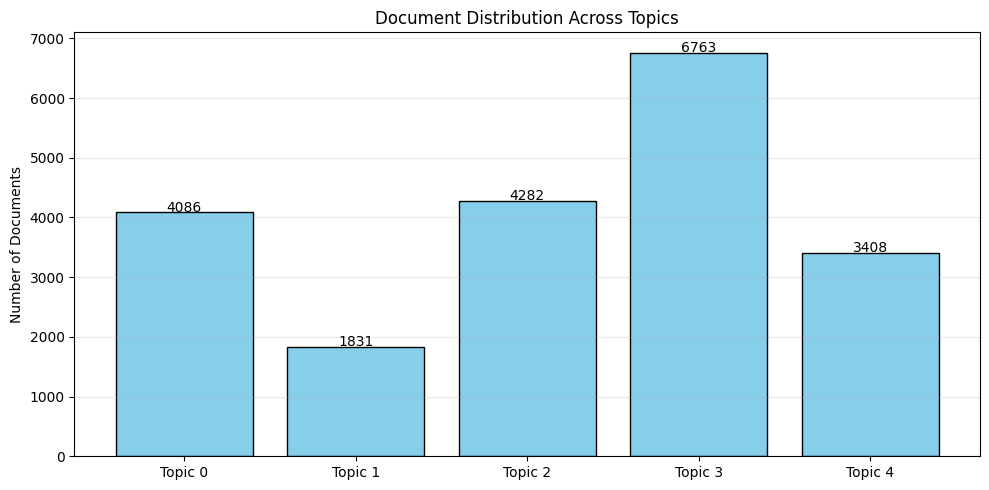

In [6]:
# Visualize topic distribution
fig, ax = plt.subplots(figsize=(10, 5))

topic_counts = df['dominant_topic'].value_counts().sort_index()
ax.bar([f'Topic {i}' for i in topic_counts.index], topic_counts.values, color='skyblue', edgecolor='black')
ax.set_ylabel('Number of Documents')
ax.set_title('Document Distribution Across Topics')
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(topic_counts.values):
    ax.text(i, v + 10, str(v), ha='center')

plt.tight_layout()
plt.show()

sentiment        Negative   Neutral   Positive
dominant_topic                                
0               91.067058  2.031326   6.901615
1               71.381759  5.679956  22.938285
2               86.361513  2.802429  10.836058
3               35.590714  6.210262  58.199024
4               88.526995  2.787559   8.685446


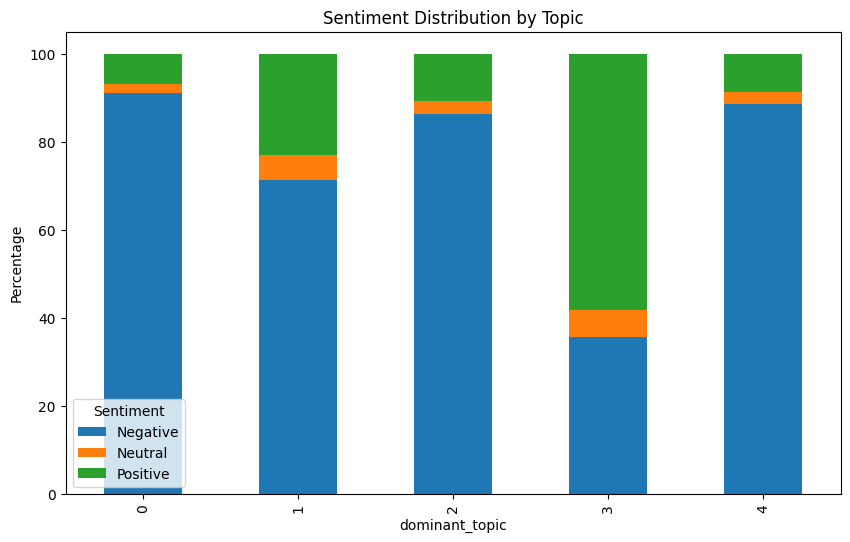

In [10]:
topic_sentiment = pd.crosstab(
    df['dominant_topic'],
    df['sentiment'],
    normalize='index'
) * 100

print(topic_sentiment)

topic_sentiment.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.ylabel('Percentage')
plt.title('Sentiment Distribution by Topic')
plt.legend(title='Sentiment')
plt.show()

In [11]:
# Save topic results
import json
from pathlib import Path

results = {
    'n_topics': n_topics,
    'topics': topics,
    'doc_topic_distribution': doc_topic_dist.tolist(),
    'dominant_topic_per_doc': df['dominant_topic'].tolist()
}

report_path = '../assets/reports/topic_modeling_report.json'
Path(report_path).parent.mkdir(parents=True, exist_ok=True)

with open(report_path, 'w') as f:
    json.dump(results, f, indent=2, default=str)

print(f'Topic modeling results saved to {report_path}')

Topic modeling results saved to ../assets/reports/topic_modeling_report.json
